# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="Boston", version=1, as_frame=True)
X = boston.data
y = boston.target.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (506, 13)
y shape: (506,)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


### 1. Data Preparation

In [3]:
# --- 1a. Exploratory overview ---
print('=== Dataset Summary ===')
print(X.describe().round(2))

=== Dataset Summary ===
         CRIM      ZN   INDUS     NOX      RM     AGE     DIS     TAX  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean     3.61   11.36   11.14    0.55    6.28   68.57    3.80  408.24   
std      8.60   23.32    6.86    0.12    0.70   28.15    2.11  168.54   
min      0.01    0.00    0.46    0.38    3.56    2.90    1.13  187.00   
25%      0.08    0.00    5.19    0.45    5.89   45.02    2.10  279.00   
50%      0.26    0.00    9.69    0.54    6.21   77.50    3.21  330.00   
75%      3.68   12.50   18.10    0.62    6.62   94.07    5.19  666.00   
max     88.98  100.00   27.74    0.87    8.78  100.00   12.13  711.00   

       PTRATIO       B   LSTAT  
count   506.00  506.00  506.00  
mean     18.46  356.67   12.65  
std       2.16   91.29    7.14  
min      12.60    0.32    1.73  
25%      17.40  375.38    6.95  
50%      19.05  391.44   11.36  
75%      20.20  396.22   16.96  
max      22.00  396.90   37.97  


In [4]:
# --- 1b. Check for missing values ---
print('Missing values per feature:')
print(X.isnull().sum())
print(f'Missing in target: {y.isnull().sum()}')

Missing values per feature:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64
Missing in target: 0


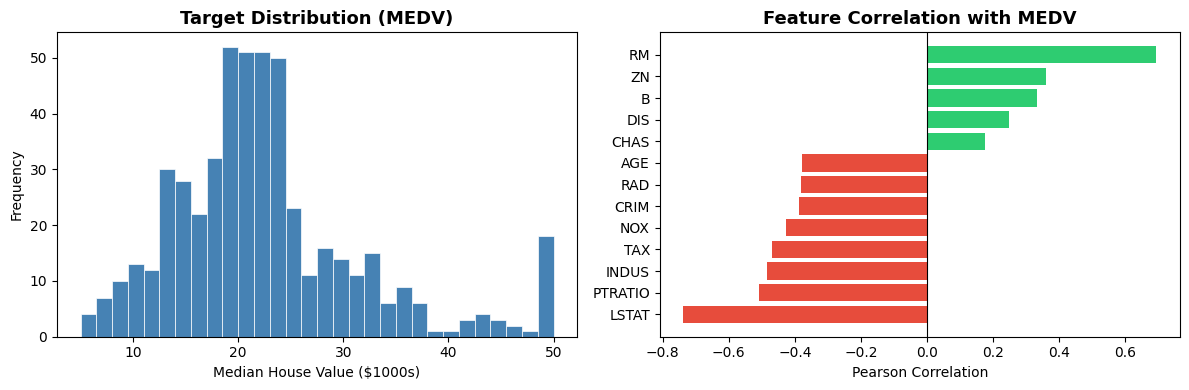

Most negatively correlated feature: LSTAT (-0.738)
Most positively correlated feature: RM (0.695)


In [5]:
# --- 1c. Visualise target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Distribution (MEDV)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median House Value ($1000s)')
axes[0].set_ylabel('Frequency')

# Correlation with target
corr = X.corrwith(y).sort_values()
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in corr]
axes[1].barh(corr.index, corr.values, color=colors)
axes[1].set_title('Feature Correlation with MEDV', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Most negatively correlated feature:', corr.index[0], f'({corr.iloc[0]:.3f})')
print('Most positively correlated feature:', corr.index[-1], f'({corr.iloc[-1]:.3f})')

In [6]:
# --- 1d. Train / Test split (80 / 20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

Training set : (404, 13)
Test set     : (102, 13)


In [7]:
# --- 1e. Feature scaling (StandardScaler) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print('Scaling complete.')
print(f'  Train mean ≈ {X_train_scaled.mean():.4f}  (should be ~0)')
print(f'  Train std  ≈ {X_train_scaled.std():.4f}   (should be ~1)')

Scaling complete.
  Train mean ≈ -0.0000  (should be ~0)
  Train std  ≈ 1.0000   (should be ~1)


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [8]:
# --- 2a. Train ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print('Linear Regression trained.')
print(f'  Intercept (β₀): {lr.intercept_:.4f}')

Linear Regression trained.
  Intercept (β₀): 22.7965


In [9]:
# --- 2b. Predictions ---
y_pred_lr = lr.predict(X_test_scaled)
print('Sample predictions vs actual (first 10):')
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred_lr[:10].round(2)})
print(comparison.to_string(index=False))

Sample predictions vs actual (first 10):
 Actual  Predicted
   23.6      29.00
   32.4      36.03
   13.6      14.82
   22.8      25.03
   16.1      18.77
   20.0      23.25
   17.8      17.66
   14.0      14.34
   19.6      23.01
   16.8      20.63


In [10]:
# --- 2c. Evaluation metrics ---
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = lr.score(X_test_scaled, y_test)

print('='*35)
print('  LINEAR REGRESSION — TEST METRICS')
print('='*35)
print(f'  MAE  : {mae_lr:.4f}')
print(f'  MSE  : {mse_lr:.4f}')
print(f'  RMSE : {rmse_lr:.4f}')
print(f'  R²   : {r2_lr:.4f}')
print('='*35)

  LINEAR REGRESSION — TEST METRICS
  MAE  : 3.1891
  MSE  : 24.2911
  RMSE : 4.9286
  R²   : 0.6688


Learned Linear Equation (standardised features):
MEDV = 22.797
       - 3.6117 × LSTAT
       + 3.1452 × RM
       - 3.0819 × DIS
       + 2.2514 × RAD
       - 2.0378 × PTRATIO
       - 2.0223 × NOX
       - 1.7670 × TAX
       + 1.1296 × B
       - 1.0021 × CRIM
       + 0.7187 × CHAS
       + 0.6963 × ZN
       + 0.2781 × INDUS
       - 0.1760 × AGE


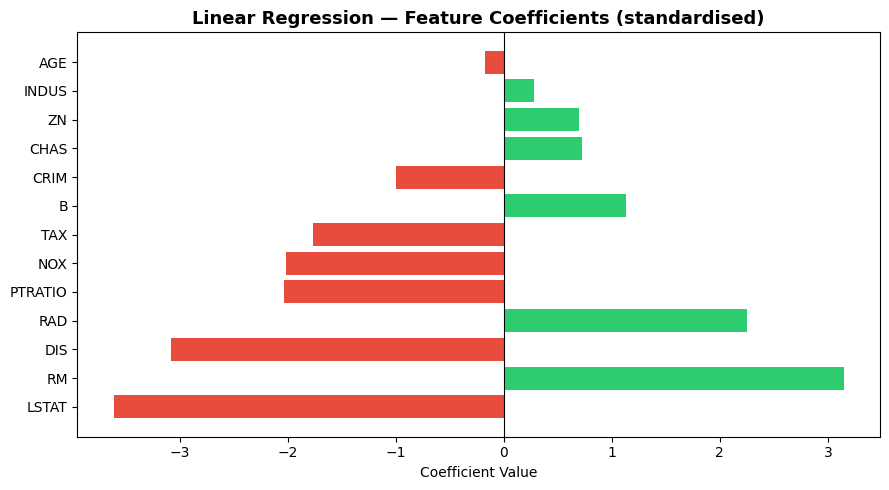

In [11]:
# --- 2d. Learned equation (top 5 features by |coef|) ---
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print('Learned Linear Equation (standardised features):')
print(f'MEDV = {lr.intercept_:.3f}')
for _, row in coef_df.iterrows():
    sign = '+' if row['Coefficient'] >= 0 else '-'
    print(f'       {sign} {abs(row["Coefficient"]):.4f} × {row["Feature"]}')

# Plot coefficients
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression — Feature Coefficients (standardised)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [12]:
# --- 3a. Create polynomial features (degree = 2) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

print(f'Original features   : {X_train_scaled.shape[1]}')
print(f'Polynomial features : {X_train_poly.shape[1]}')
print('(includes all original, squared, and interaction terms)')

Original features   : 13
Polynomial features : 104
(includes all original, squared, and interaction terms)


In [13]:
# --- 3b. Train ---
pr = LinearRegression()
pr.fit(X_train_poly, y_train)
print('Polynomial Regression (degree=2) trained.')

Polynomial Regression (degree=2) trained.


In [14]:
# --- 3c. Predictions ---
y_pred_pr = pr.predict(X_test_poly)
print('Sample predictions vs actual (first 10):')
comparison_poly = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred_pr[:10].round(2)})
print(comparison_poly.to_string(index=False))

Sample predictions vs actual (first 10):
 Actual  Predicted
   23.6      27.02
   32.4      34.88
   13.6      14.40
   22.8      21.03
   16.1      16.34
   20.0      16.73
   17.8      16.76
   14.0      14.67
   19.6      22.43
   16.8      19.08


In [15]:
# --- 3d. Evaluation metrics ---
mae_pr  = mean_absolute_error(y_test, y_pred_pr)
mse_pr  = mean_squared_error(y_test, y_pred_pr)
rmse_pr = np.sqrt(mse_pr)
r2_pr   = pr.score(X_test_poly, y_test)

print('='*38)
print('  POLYNOMIAL REGRESSION — TEST METRICS')
print('='*38)
print(f'  MAE  : {mae_pr:.4f}')
print(f'  MSE  : {mse_pr:.4f}')
print(f'  RMSE : {rmse_pr:.4f}')
print(f'  R²   : {r2_pr:.4f}')
print('='*38)

  POLYNOMIAL REGRESSION — TEST METRICS
  MAE  : 2.5748
  MSE  : 14.2573
  RMSE : 3.7759
  R²   : 0.8056


In [16]:
# --- 3e. Top polynomial terms ---
feat_names = poly.get_feature_names_out(X.columns)
poly_coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': pr.coef_})
poly_coef_df = poly_coef_df.reindex(poly_coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print('Top 10 polynomial terms by |coefficient|:')
print(poly_coef_df.head(10).to_string(index=False))

Top 10 polynomial terms by |coefficient|:
     Feature  Coefficient
    CRIM TAX   -52.446558
  CRIM INDUS    34.223339
    CRIM RAD    23.789450
     CRIM ZN    16.150896
         TAX   -14.303876
CRIM PTRATIO    12.875776
       INDUS    11.579095
     RAD TAX    11.418825
       RAD^2    -9.058736
         RAD     6.862731


### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


In [17]:
# --- 4a. Metrics table ---
metrics = pd.DataFrame({
    'Metric':     ['MAE', 'MSE', 'RMSE', 'R²', '# Features'],
    'Linear Reg': [f'{mae_lr:.4f}',  f'{mse_lr:.4f}',  f'{rmse_lr:.4f}', f'{r2_lr:.4f}',  '13'],
    'Poly Reg':   [f'{mae_pr:.4f}',  f'{mse_pr:.4f}',  f'{rmse_pr:.4f}', f'{r2_pr:.4f}', '104'],
    'Better':     [
        '✅ Linear' if mae_lr  < mae_pr  else '✅ Poly',
        '✅ Linear' if mse_lr  < mse_pr  else '✅ Poly',
        '✅ Linear' if rmse_lr < rmse_pr else '✅ Poly',
        '✅ Linear' if r2_lr   > r2_pr   else '✅ Poly',
        '—'
    ]
})
print(metrics.to_string(index=False))

    Metric Linear Reg Poly Reg Better
       MAE     3.1891   2.5748 ✅ Poly
       MSE    24.2911  14.2573 ✅ Poly
      RMSE     4.9286   3.7759 ✅ Poly
        R²     0.6688   0.8056 ✅ Poly
# Features         13      104      —


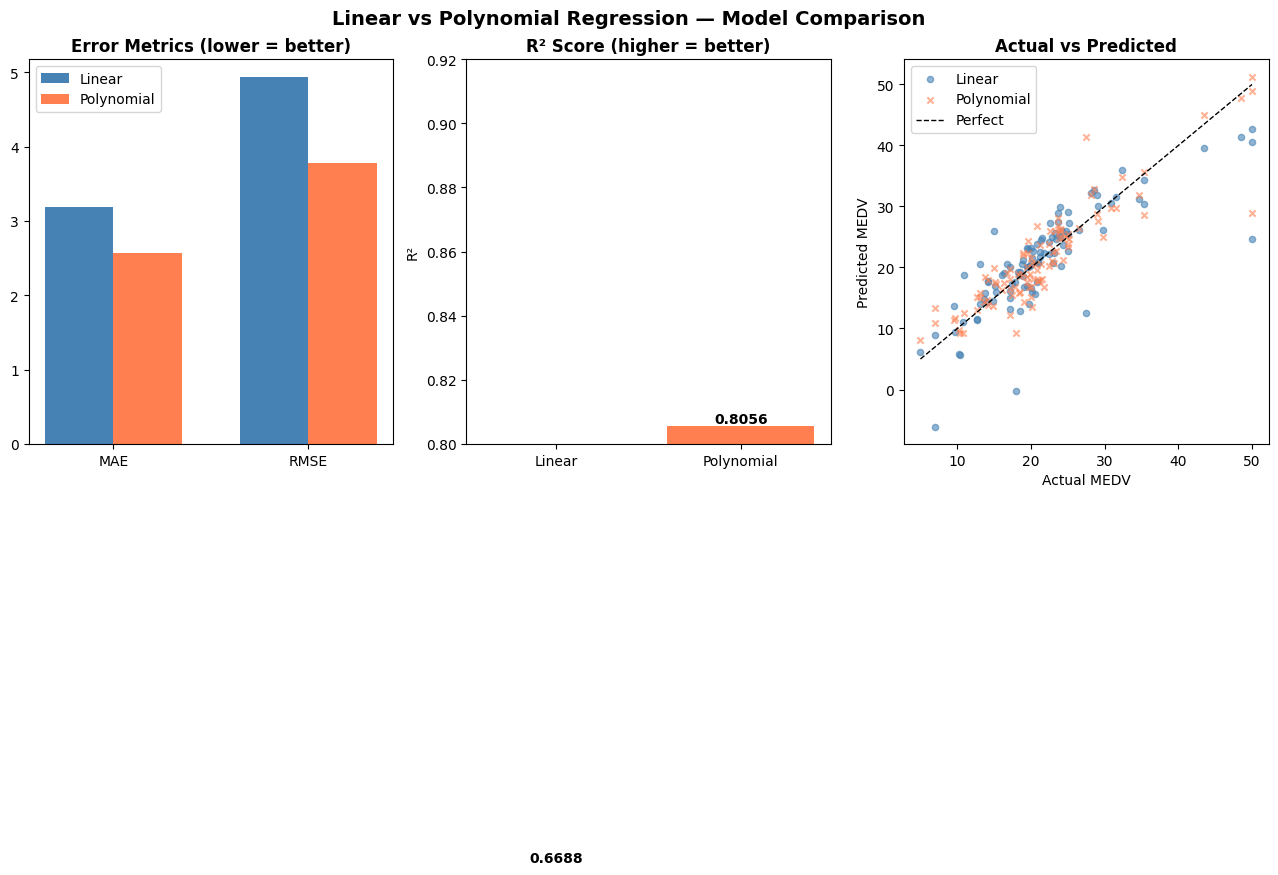

Comparison chart saved.


In [18]:
# --- 4b. Visual comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Linear vs Polynomial Regression — Model Comparison', fontsize=14, fontweight='bold')

# Bar chart: MAE, RMSE, R²
metric_names = ['MAE', 'RMSE']
lr_vals  = [mae_lr,  rmse_lr]
pr_vals  = [mae_pr,  rmse_pr]
x = np.arange(len(metric_names))
width = 0.35
axes[0].bar(x - width/2, lr_vals, width, label='Linear', color='steelblue')
axes[0].bar(x + width/2, pr_vals, width, label='Polynomial', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_title('Error Metrics (lower = better)', fontweight='bold')
axes[0].legend()

# R² comparison
axes[1].bar(['Linear', 'Polynomial'], [r2_lr, r2_pr], color=['steelblue', 'coral'])
axes[1].set_ylim(0.8, 0.92)
axes[1].set_title('R² Score (higher = better)', fontweight='bold')
axes[1].set_ylabel('R²')
for i, v in enumerate([r2_lr, r2_pr]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Actual vs Predicted scatter
axes[2].scatter(y_test, y_pred_lr, alpha=0.6, label='Linear', color='steelblue', s=20)
axes[2].scatter(y_test, y_pred_pr, alpha=0.6, label='Polynomial', color='coral', s=20, marker='x')
mn, mx = y_test.min(), y_test.max()
axes[2].plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='Perfect')
axes[2].set_xlabel('Actual MEDV')
axes[2].set_ylabel('Predicted MEDV')
axes[2].set_title('Actual vs Predicted', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

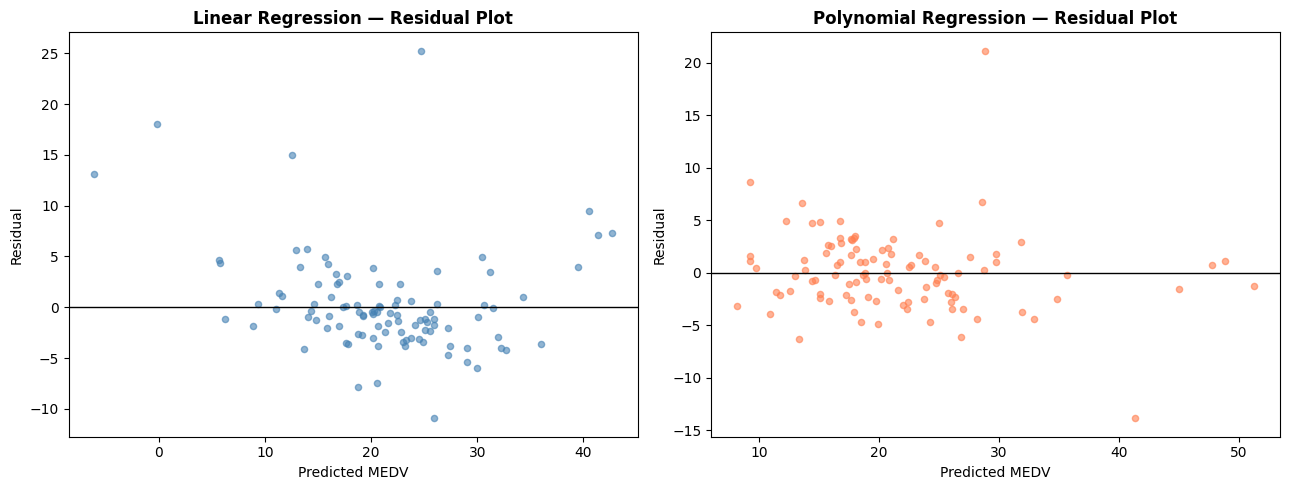

In [19]:
# --- 4c. Residuals ---
res_lr = y_test - y_pred_lr
res_pr = y_test - y_pred_pr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res, label, color in zip(axes, [res_lr, res_pr],
                                  ['Linear', 'Polynomial'], ['steelblue', 'coral']):
    ax.scatter(y_pred_lr if label=='Linear' else y_pred_pr, res,
               alpha=0.6, color=color, s=20)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Predicted MEDV')
    ax.set_ylabel('Residual')
    ax.set_title(f'{label} Regression — Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()